In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



In [27]:
import pandas as pd

df = pd.read_csv("../data/outputs/provider_level.csv")
df

,billing_provider_npi,months_active,sum_paid,mean_paid,median_paid,max_paid,mean_paid_per_claim,median_paid_per_claim,std_paid_per_claim,claim_weighted_paid_per_claim,...,max_monthlyized_hhi_change,mean_monthlyized_hhi_change,num_months_high_hhi_change,mean_hcpcs_count,max_hcpcs_count,std_hcpcs_count,hcpcs_count_trend,fraction_months_single_code,insufficient_history_flag,label
0,1003001371,81,72670.15,897.162346,666.11,4804.04,25.422289,22.440263,13.762478,25.935100,...,0.670799,0.132960,27,1.629630,5.0,0.967528,0.012873,0.604938,0,0
1,1003002726,41,237220.00,5785.853659,5792.00,8552.00,105.553145,100.242424,7.072922,106.186213,...,0.000000,0.000000,0,1.000000,1.0,0.000000,0.000000,1.000000,0,0
2,1003006529,36,45491.28,1263.646667,1180.30,4901.00,25.136475,22.977075,10.155297,22.565119,...,0.657632,0.204178,30,3.527778,7.0,1.843694,0.012227,0.194444,0,0
3,1003008285,22,163785.40,7444.790909,10668.35,17291.90,38.670156,41.777360,10.671828,44.664685,...,0.454415,0.054196,2,5.272727,10.0,3.930126,0.533032,0.409091,0,0
4,1003009630,47,24690.05,525.320213,508.76,1000.10,24.464821,24.036333,7.346922,23.447341,...,0.630597,0.185029,22,1.404255,3.0,0.648060,-0.000925,0.680851,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17542,1992978654,84,197143.23,2346.943214,2199.75,4108.88,38.540030,36.437208,10.597174,35.766188,...,0.622961,0.212418,56,2.726190,7.0,1.425678,-0.015845,0.238095,0,0
17543,1992981179,83,14792.71,178.225422,168.53,839.78,2.952184,2.765238,1.111645,3.012772,...,0.617509,0.153205,52,1.891566,4.0,0.541273,-0.004933,0.192771,0,0
17544,1992986624,83,138279.26,1666.015181,1096.06,10089.03,7.335792,5.261905,8.169323,5.468177,...,0.499980,0.157520,52,2.253012,5.0,1.323736,0.035641,0.373494,0,0
17545,1992988604,19,6919.36,364.176842,225.78,1529.95,8.680308,6.450857,5.007986,10.777819,...,0.559708,0.234280,15,1.947368,4.0,0.911268,0.010526,0.368421,0,0


In [28]:
df['label'].value_counts()

label
0    17523
1       24
Name: count, dtype: int64

In [29]:
missing = df.isna().sum()
missing_rows = df.isna().any(axis=1).sum()
print(f"Rows with at least one NaN: {missing_rows} / {len(df)} ({missing_rows/len(df):.1%})")
missing[missing > 0]


Rows with at least one NaN: 0 / 17547 (0.0%)


Series([], dtype: int64)

In [30]:
df['changepoint_count_paid'].describe()

count    17547.000000
mean         0.839232
std          0.944652
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: changepoint_count_paid, dtype: float64

In [31]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

exclude = ['label', 'billing_provider_npi', 'insufficient_history_flag']
features = [col for col in df.columns if col not in exclude]

rows = []
for feat in features:
    valid = df[['label', feat]].dropna()
    if valid['label'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid['label'], valid[feat])
        auc = max(auc, 1 - auc)  # flip if below 0.5
        rows.append({'feature': feat, 'auroc': round(auc, 4)})
    except Exception:
        continue

auroc_df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)
auroc_df

,feature,auroc
0,mean_paid,0.6870
1,median_paid,0.6848
2,fraction_months_single_code,0.6666
3,mean_abs_monthlyized_change_paid,0.6642
4,max_paid,0.6640
5,largest_monthlyized_paid_drop,0.6610
6,mad_paid,0.6523
7,sum_paid,0.6302
8,max_monthlyized_paid_growth,0.6236
9,cv_paid,0.6213


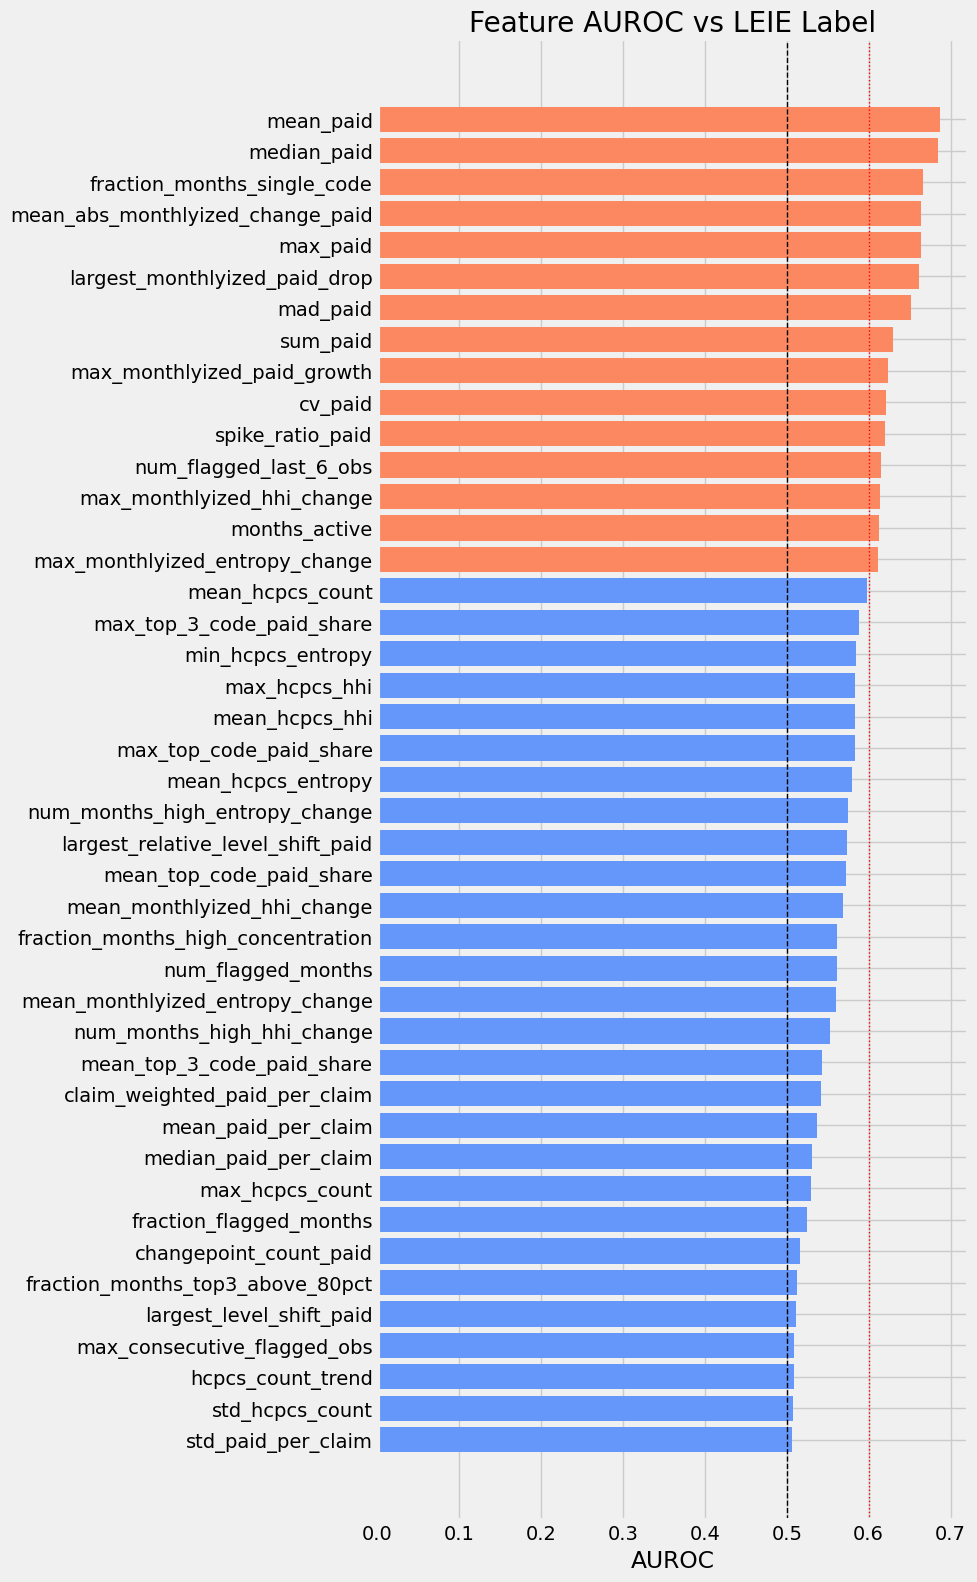

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

exclude = ['label', 'billing_provider_npi', 'insufficient_history_flag']
features = [col for col in df.columns if col not in exclude]

rows = []
for feat in features:
    valid = df[['label', feat]].dropna()
    if valid['label'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid['label'], valid[feat])
        auc = max(auc, 1 - auc)
        rows.append({'feature': feat, 'auroc': round(auc, 4)})
    except Exception:
        continue

auroc_df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(auroc_df) * 0.35 + 1))
colors = ['#FB8861' if v >= 0.6 else '#6497F9' for v in auroc_df['auroc']]
ax.barh(auroc_df['feature'], auroc_df['auroc'], color=colors)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.axvline(0.6, color='red', linestyle=':', linewidth=1)
ax.set_xlabel('AUROC')
ax.set_title('Feature AUROC vs LEIE Label')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


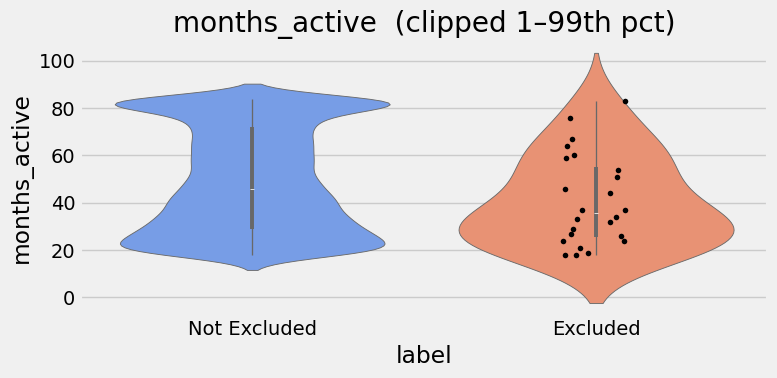

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


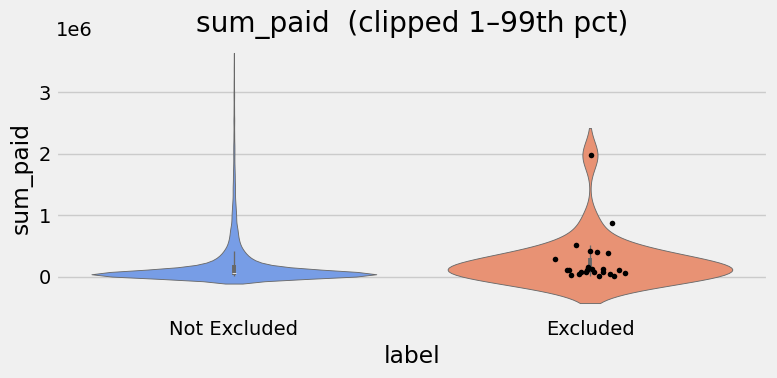

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


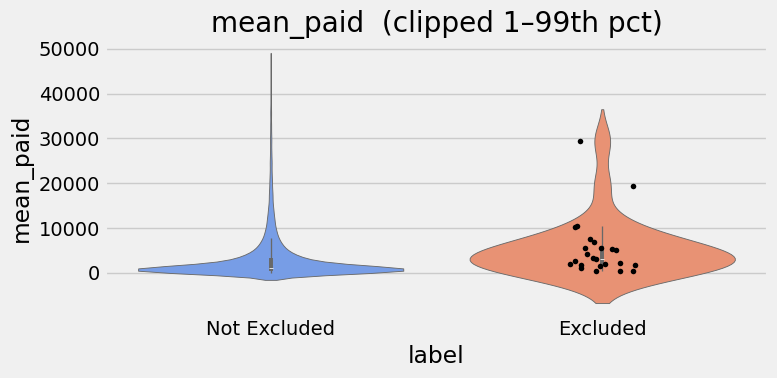

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


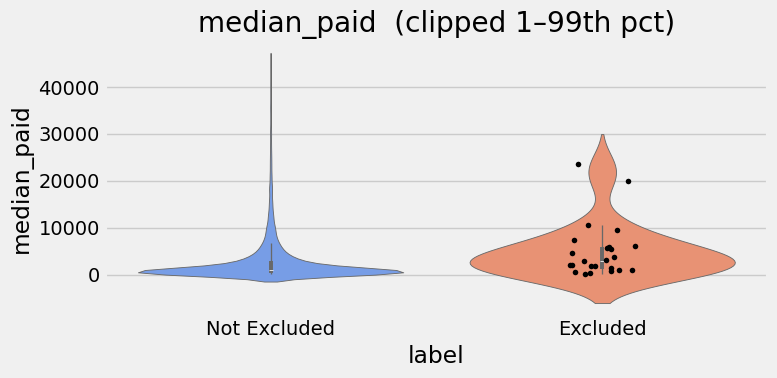

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


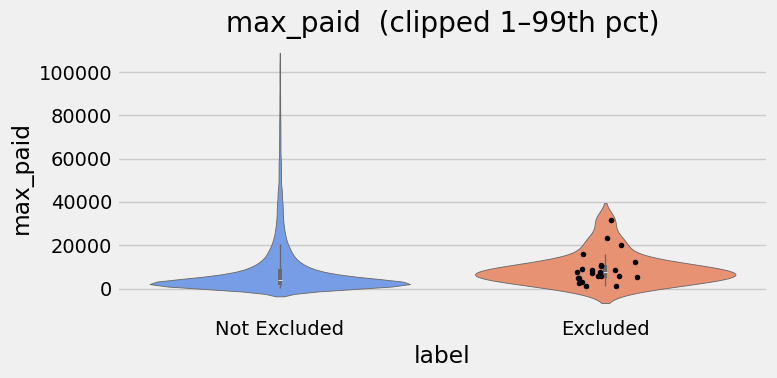

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


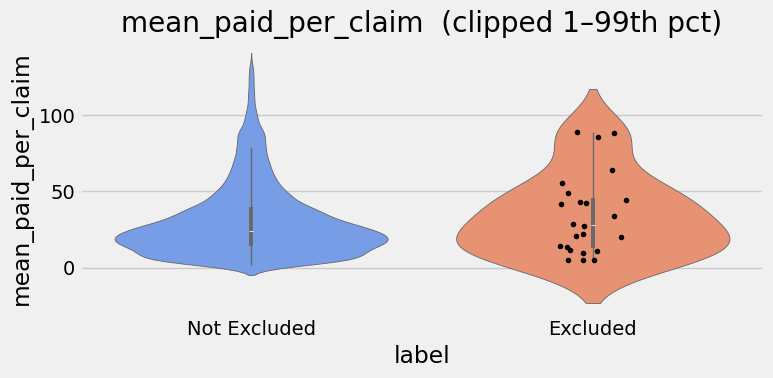

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


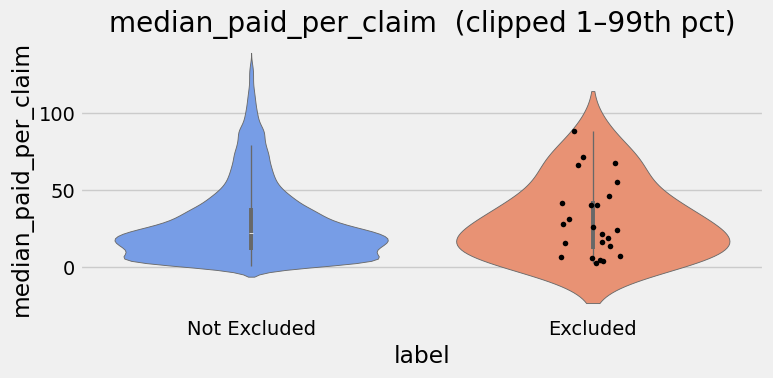

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


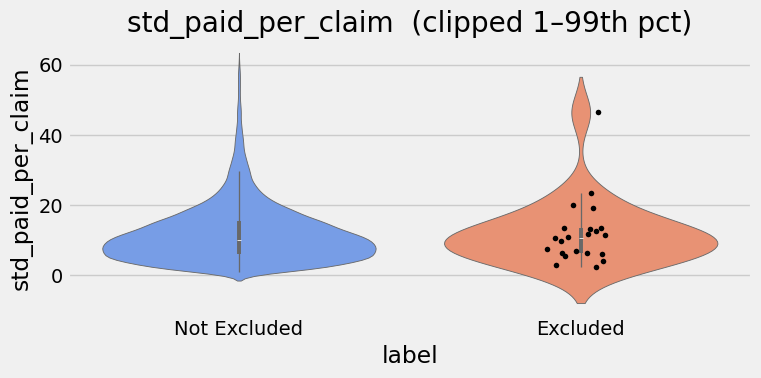

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


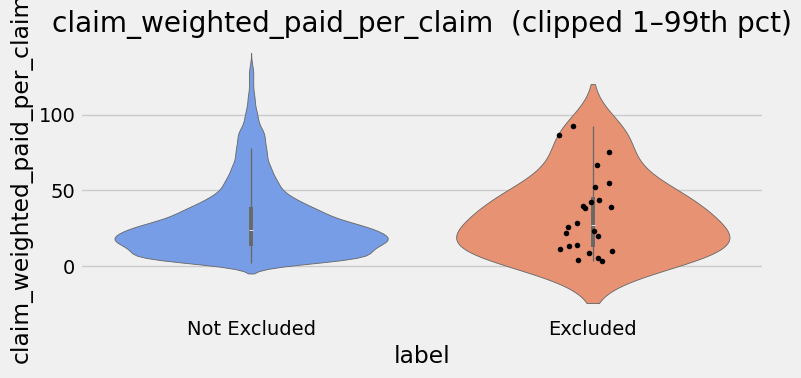

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


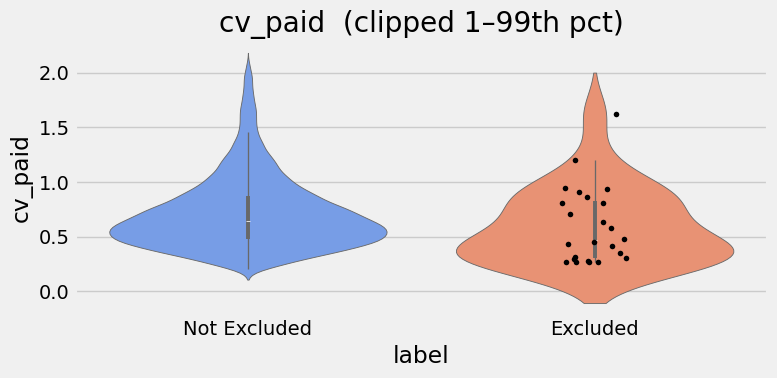

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


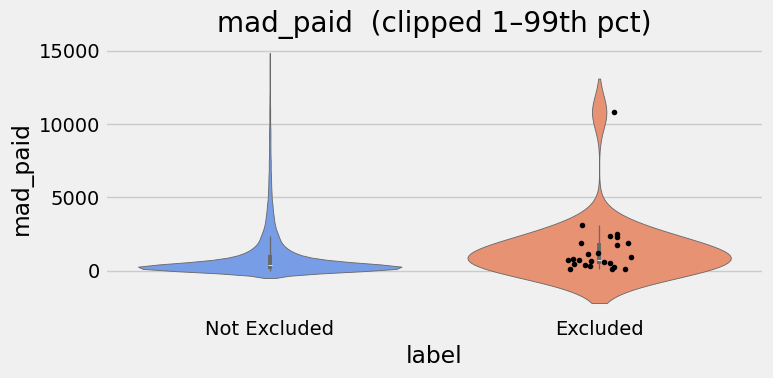

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


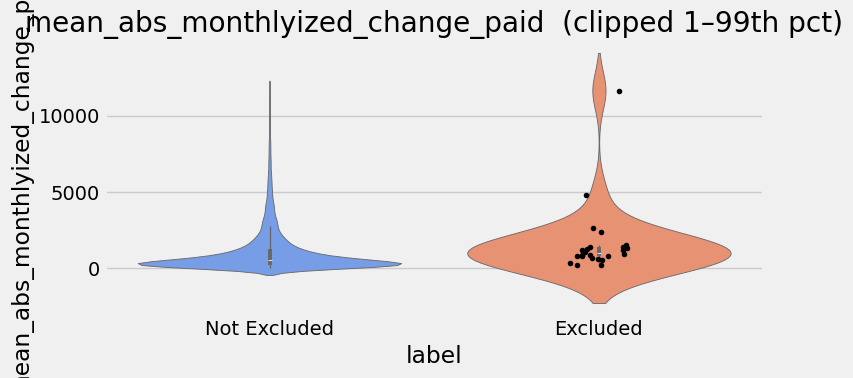

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


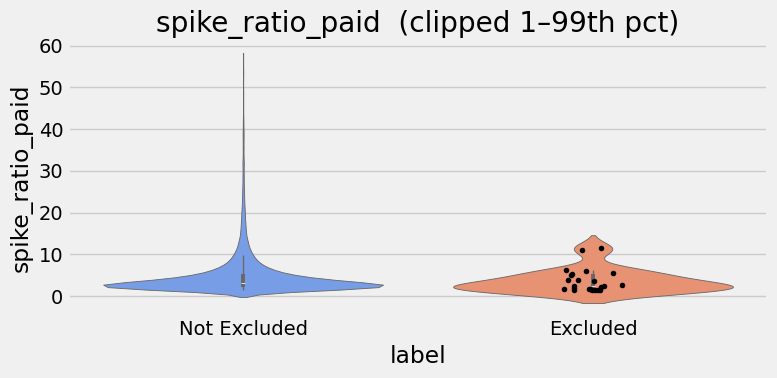

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


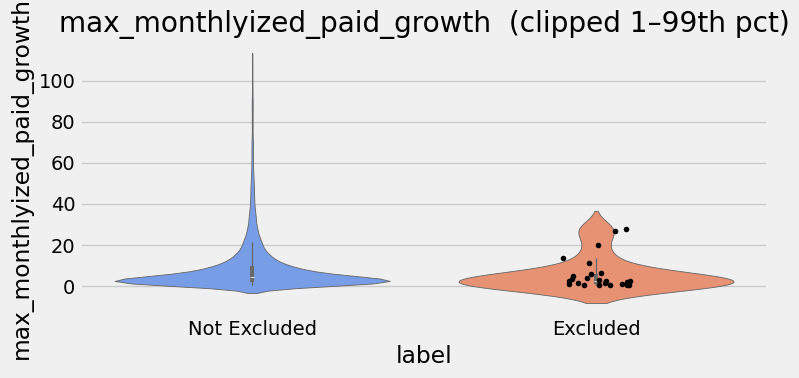

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


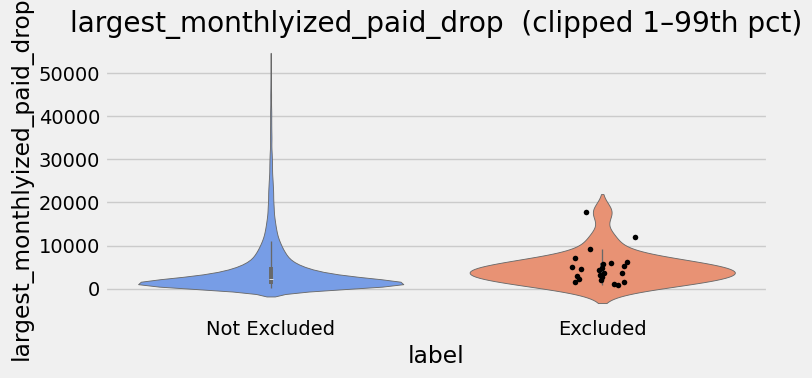

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


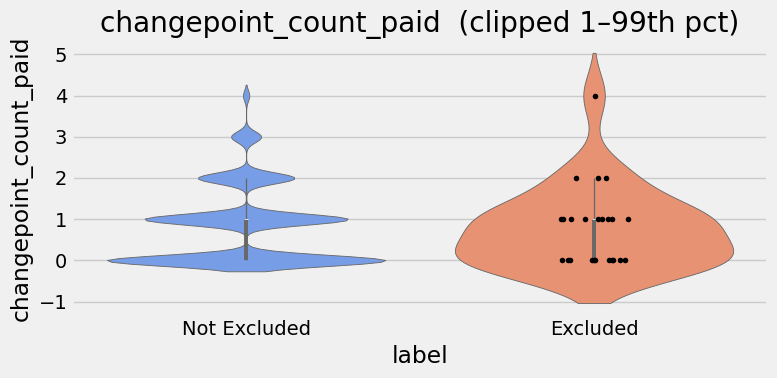

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


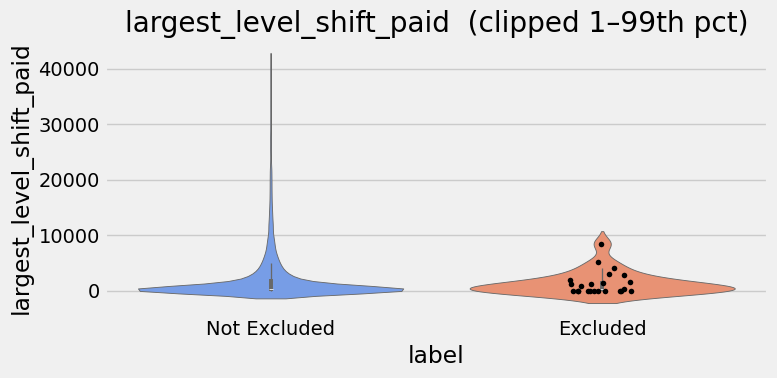

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


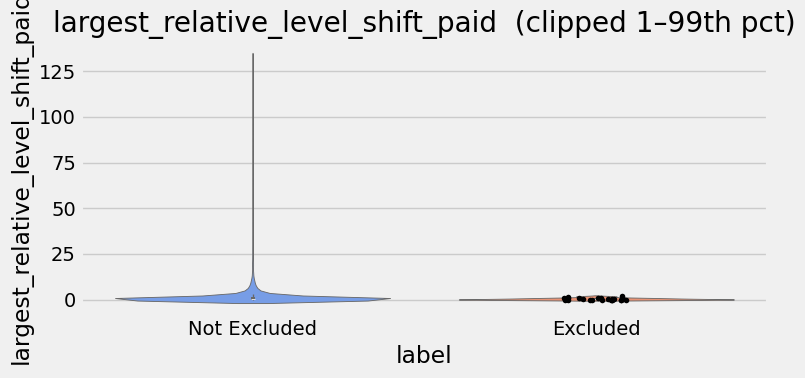

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


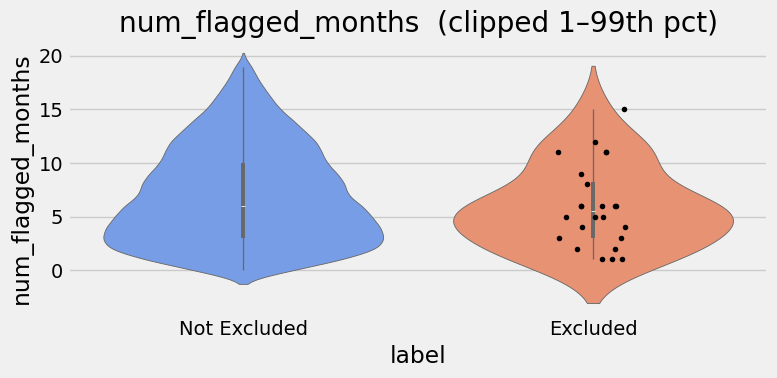

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


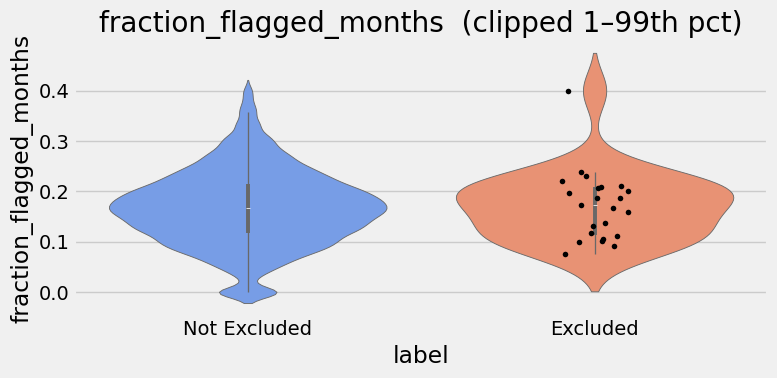

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


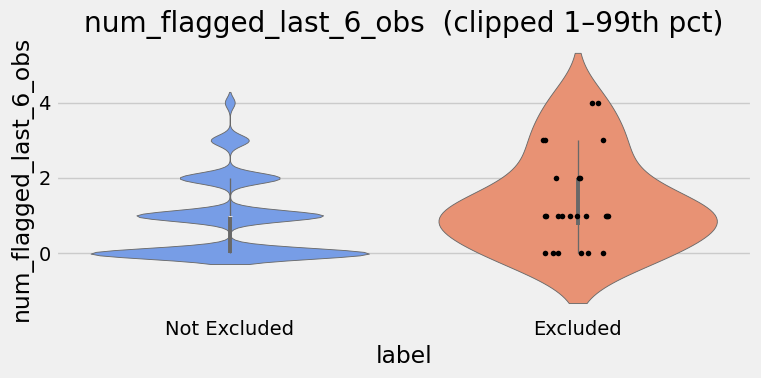

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


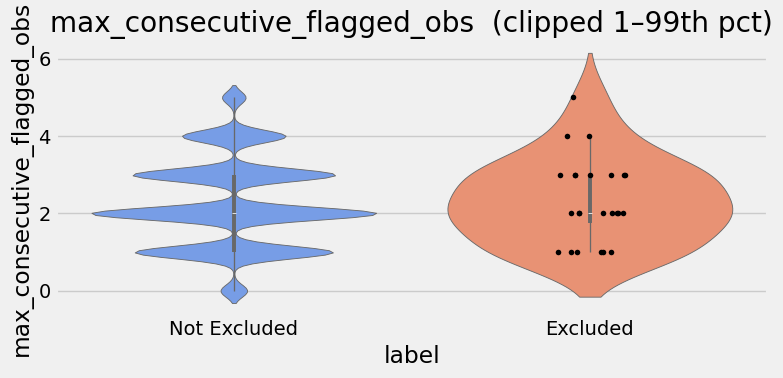

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


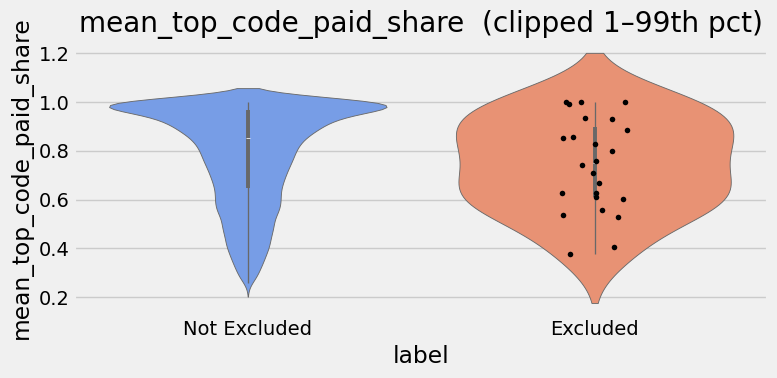

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


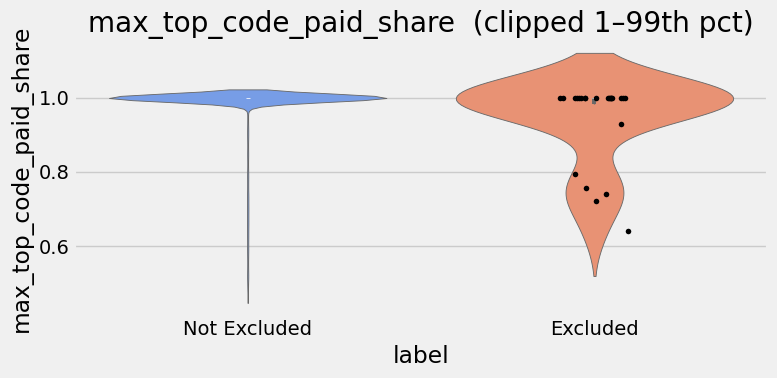

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


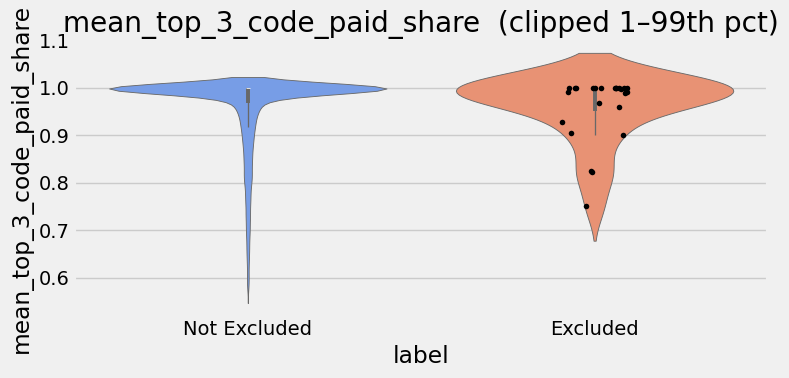

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


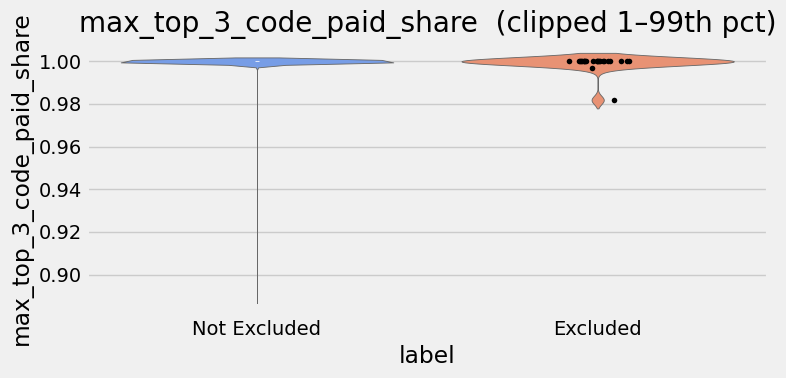

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


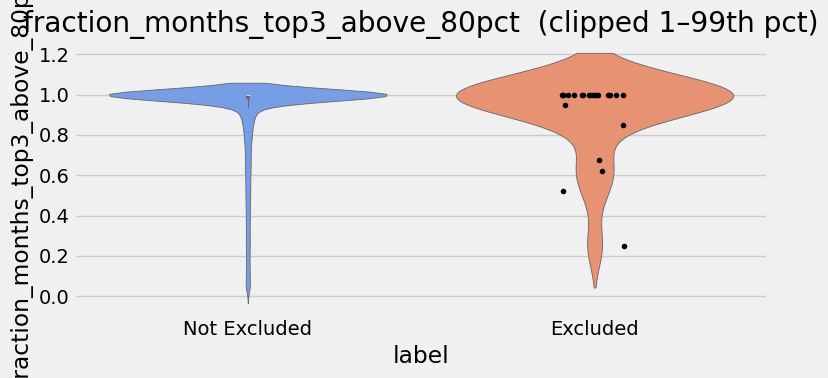

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


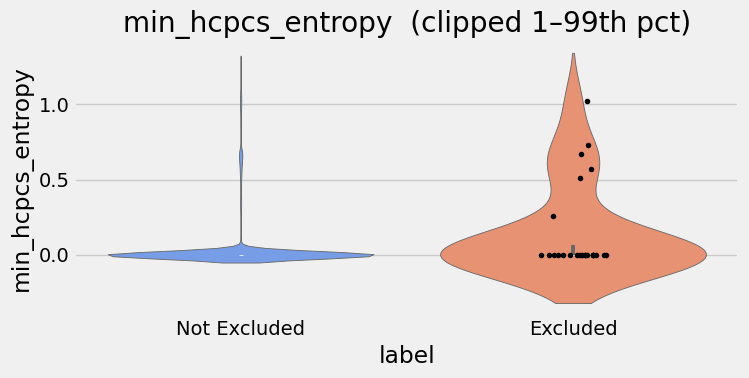

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


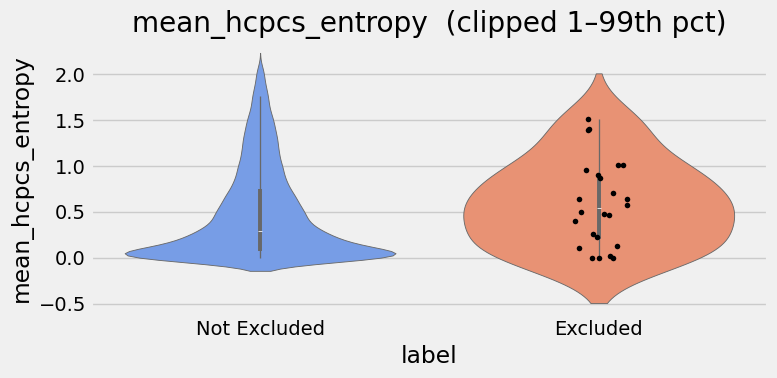

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


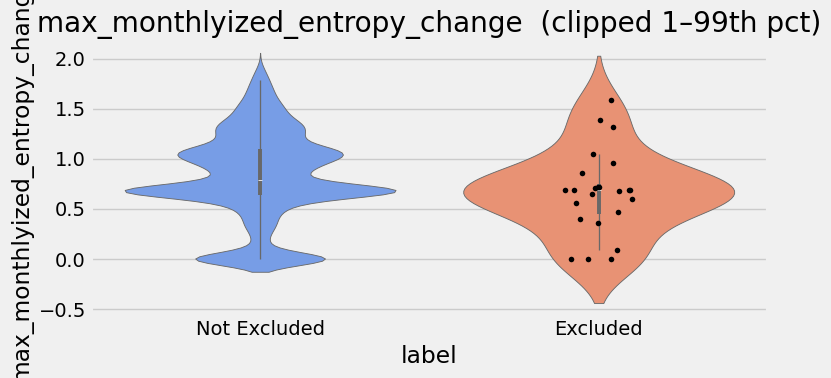

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


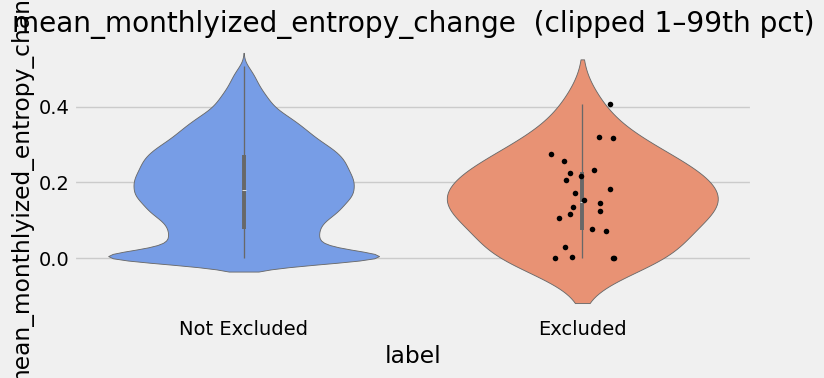

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


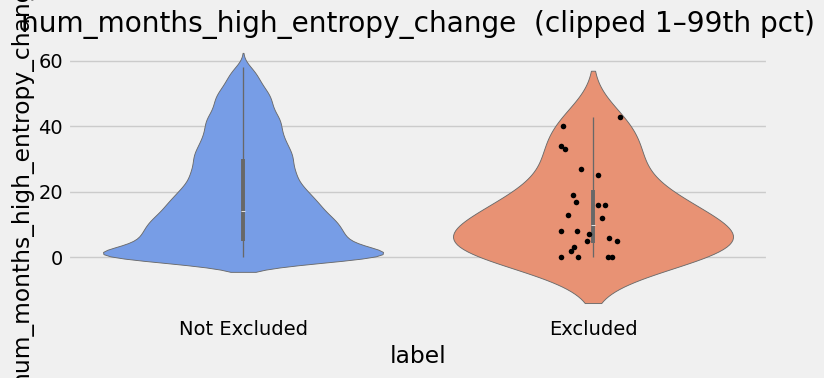

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


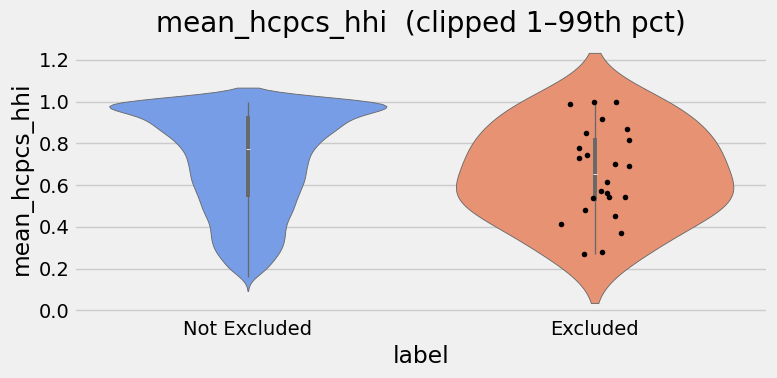

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


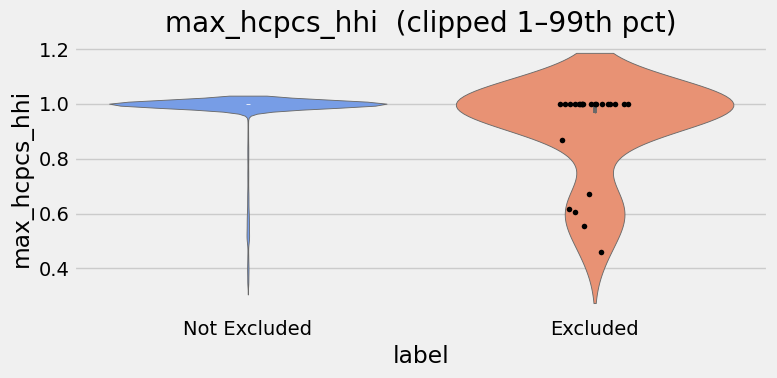

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


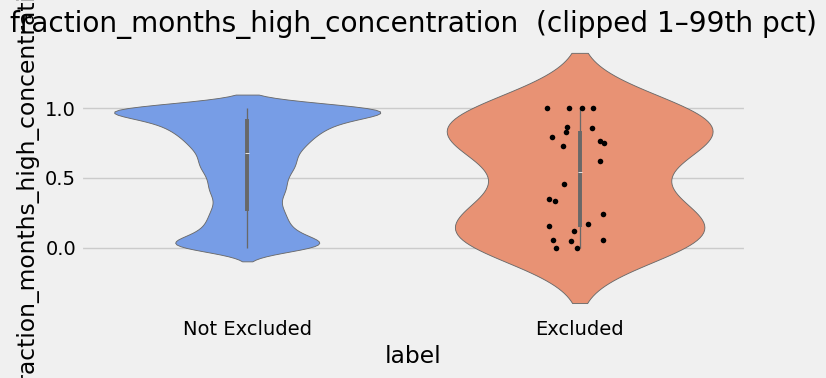

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


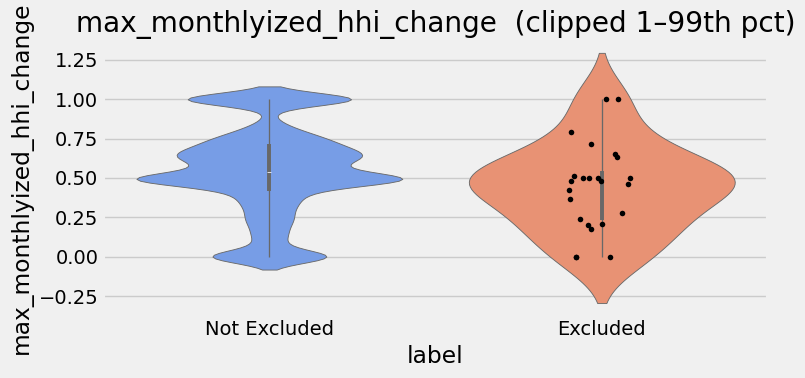

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


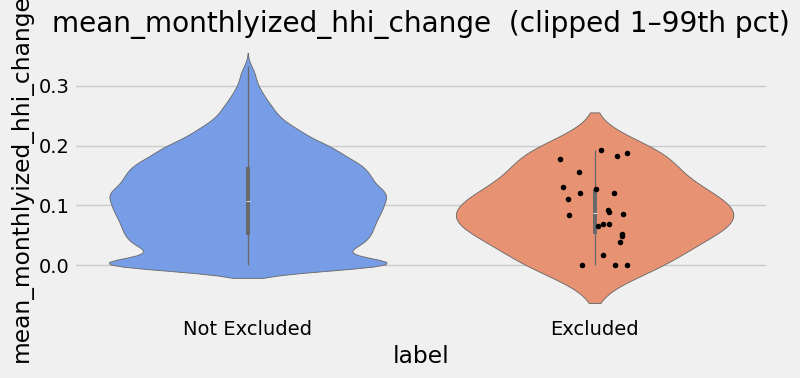

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


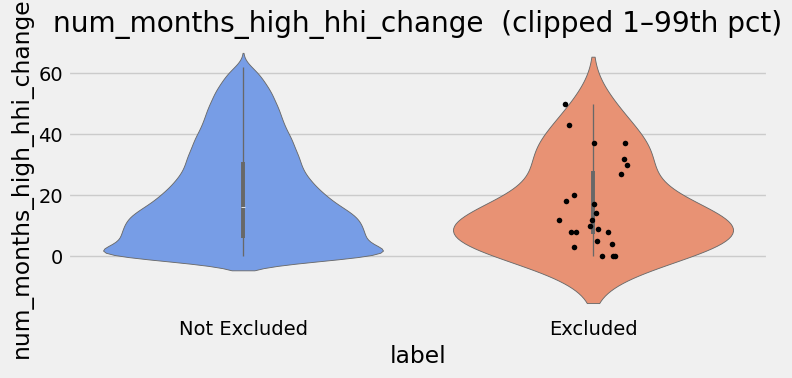

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


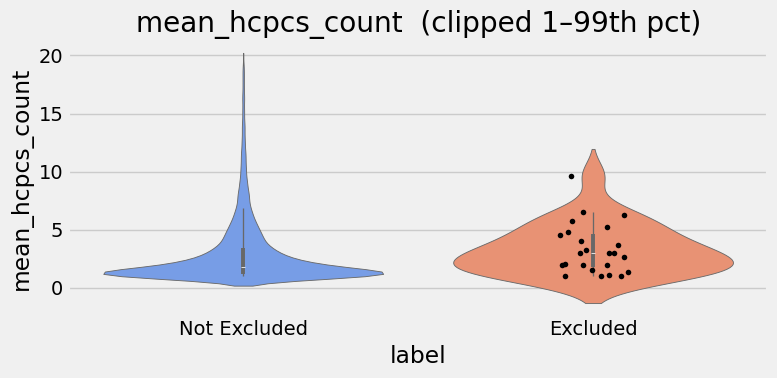

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


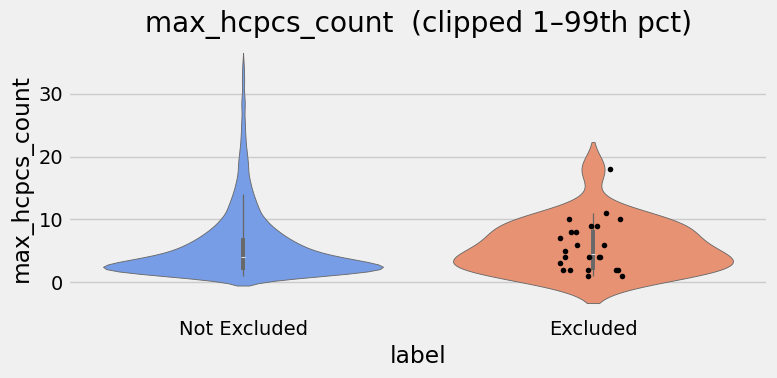

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


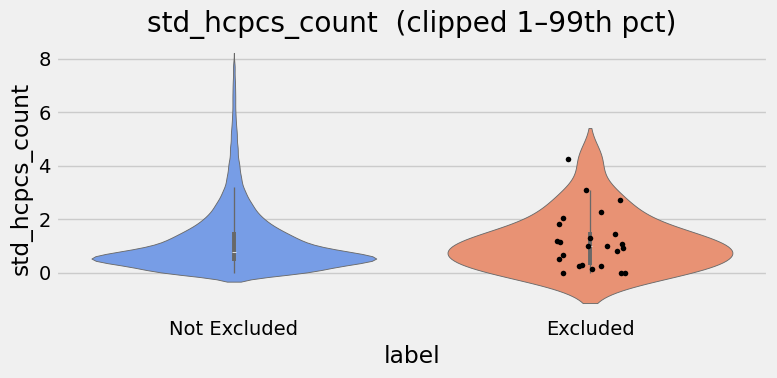

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


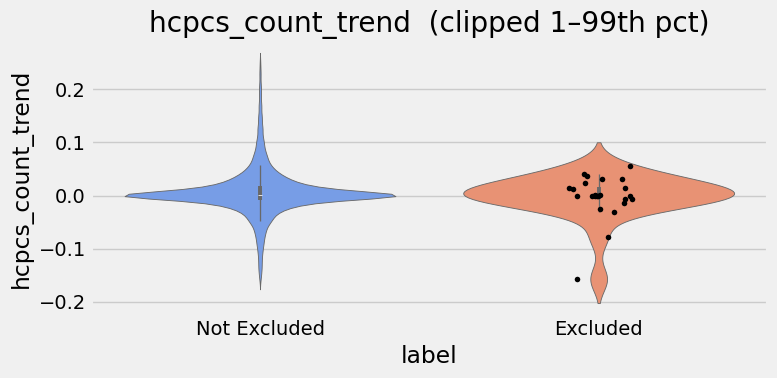

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_54630/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


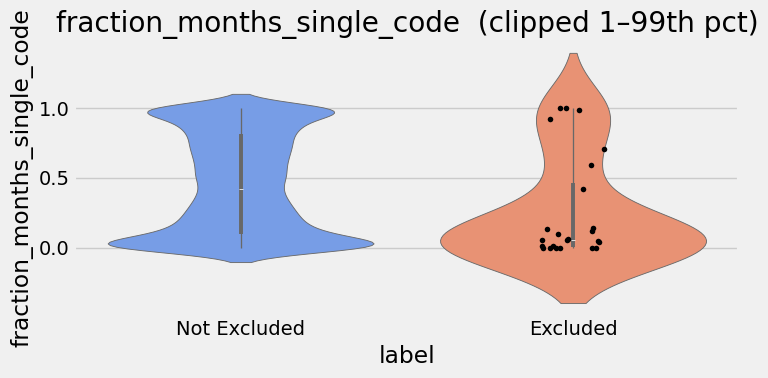

In [34]:
for feat in features:
    fig, ax = plt.subplots(figsize=(8, 4))
    
    q01 = df[feat].quantile(0.01)
    q99 = df[feat].quantile(0.99)
    plot_df = df[df[feat].between(q01, q99)]
    
    sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
    sns.stripplot(data=plot_df[plot_df['label']==1], x='label', y=feat, ax=ax, color='black', size=4, jitter=True)
    ax.set_title(f'{feat}  (clipped 1–99th pct)')
    ax.set_xticklabels(['Not Excluded', 'Excluded'])
    plt.tight_layout()
    plt.show()

In [33]:
from sklearn.ensemble import IsolationForest

exclude = ['label', 'billing_provider_npi', 'insufficient_history_flag']
features = [col for col in df.columns if col not in exclude]

X = df[features].dropna()
idx = X.index

iso = IsolationForest(contamination=0.013, random_state=42)
iso.fit(X)
scores = -iso.score_samples(X)  # higher = more anomalous

results = df.loc[idx, ['billing_provider_npi', 'label']].copy()
results['anomaly_score'] = scores
results = results.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

base_rate = results['label'].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}")

for k in [50, 100, 200, 500]:
    top_k = results.head(k)
    hits = top_k['label'].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float('nan')
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")


Base rate (LEIE prevalence): 0.0014
Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  100  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  200  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  500  |  LEIE hits:   1  |  Precision: 0.0020  |  Lift: 1.46x
